<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/fetch_20newsgroups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import fetch_20newsgroups

# Step 1 — Load the dataset
import pandas as pd
import numpy as np





# Step 1 — Load dataset

#data = fetch_20newsgroups()
data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Step 2 — Create DataFrame
df = pd.DataFrame({'document': data.data})

# Step 3 — Add target as number
df['target'] = data.target
df['target_name'] = np.array(data.target_names)[data.target]

print("Shape:", df.shape)
print("Classes:", df['target'].value_counts())
print("Class counts:\n", df['target_name'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Shape: (18846, 3)
Classes: target
10    999
15    997
8     996
9     994
11    991
7     990
13    990
5     988
14    987
2     985
12    984
3     982
6     975
1     973
4     963
17    940
16    910
0     799
18    775
19    628
Name: count, dtype: int64
Class counts:
 target_name
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

First 5 rows:
                                

In [6]:

# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target', 'target_name'])
y = df['target']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = TfidfVectorizer()
scaler.fit(X_train['document'])             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train['document'])
X_test_scaled  = scaler.transform(X_test['document'])



# Step 5 — Verify scaling worked
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\nBefore scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())


Train size: 15076
Test size: 3770

Before scaling (train set):
                                                document
12056  #\n# I've gotten very few posts on this group ...
10359  Interesting.  I'd fight the ticket.  First off...
1266   I remember as a kid visiting my relatives on K...
4602   \n\nIt can be painless, so it isn't cruel.  An...
7341   the owners are whining about baseball not bein...

AFTER scaling (train set):
                                            document
0  <Compressed Sparse Row sparse matrix of dtype ...
1  <Compressed Sparse Row sparse matrix of dtype ...
2  <Compressed Sparse Row sparse matrix of dtype ...
3  <Compressed Sparse Row sparse matrix of dtype ...
4  <Compressed Sparse Row sparse matrix of dtype ...


In [7]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=200)   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 0.7186

First test sample — true label   : 9
First test sample — predicted    : 9
First test sample — probabilities: [0.023 0.014 0.014 0.016 0.021 0.017 0.012 0.02  0.029 0.612 0.058 0.023
 0.022 0.022 0.019 0.015 0.024 0.01  0.014 0.015]


In [4]:
# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=1000))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X['document'], y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [0.735  0.732  0.7347 0.7259 0.7196]
Mean accuracy: 0.7294
Std deviation: 0.0059


In [12]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', TfidfVectorizer()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X['document'], y, cv=5)

# Step 3 — Print both results side by side
print(f"Logistic Regression — mean: {round(scores.mean(), 4)}  std: {round(scores.std(), 4)}")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

KeyboardInterrupt: 

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.56      0.56       151
           1       0.69      0.67      0.68       202
          10       0.70      0.66      0.68       195
          11       0.64      0.67      0.65       183
          12       0.81      0.70      0.75       205
          13       0.83      0.78      0.81       215
          14       0.70      0.72      0.71       193
          15       0.77      0.72      0.74       196
          16       0.43      0.78      0.56       168
          17       0.78      0.83      0.81       211
          18       0.92      0.86      0.89       198
          19       0.90      0.74      0.81       201
           2       0.67      0.71      0.69       202
           3       0.81      0.85      0.83       194
           4       0.74      0.81      0.77       189
           5       0.68      0.77      0.72       202
           6       0.75      0.73      0.74       188
    

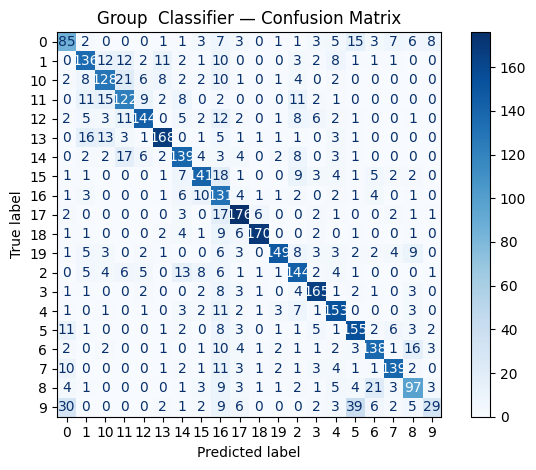

In [11]:
# ============================================================
# ROUND 1 — CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression




# Step 1 — Retrain best model (Logistic Regression) on train set
final_model = Pipeline(
    [('scaler', TfidfVectorizer()), ('model', LogisticRegression(max_iter=200))]
)
final_model.fit(X_train['document'], y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test['document'])

# Get unique class labels for target_names and display_labels
class_labels = sorted(y.unique().astype(str))

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title("Group  Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
data.target_names[9]

'rec.sport.baseball'

In [16]:
# Custom sentence → predicted category
custom_text = ["The launch of the space shuttle was delayed"]

predicted_category = final_model.predict(custom_text)[0]
predicted_label = data.target_names[predicted_category]

print(f"Input: {custom_text[0]}")
print(f"Predicted category: {predicted_label}")

Input: The launch of the space shuttle was delayed
Predicted category: sci.space
